In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
df=pd.read_csv("online_purchase_500_updated.csv")
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,7,2,2,2.0,NaN,16.0,0.51,1,0
1,20,2,6,1.0,0.0,115.0,0.45,1,0
2,29,7,1,4.0,3.0,53.0,0.22,1,0
3,15,6,15,3.0,0.0,46.0,0.36,0,0
4,11,3,10,3.0,NaN,NaN,0.45,0,0
...,...,...,...,...,...,...,...,...,...
495,12,2,11,5.0,2.0,34.0,0.54,0,0
496,19,2,8,0.0,3.0,62.0,0.53,0,0
497,23,14,10,2.0,4.0,106.0,0.71,0,0
498,15,11,7,5.0,NaN,35.0,0.77,1,0


In [3]:
df.describe()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
count,500.000000,500.000000,500.000000,450.000000,450.000000,450.000000,500.000000,500.000000,500.000000
mean,15.112000,7.440000,9.676000,2.935556,1.986667,58.700000,0.495400,0.484000,0.242000
std,8.850317,4.119264,5.576488,1.977114,1.446846,34.634409,0.229004,0.500244,0.428723
min,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000,0.100000,0.000000,0.000000
25%,7.000000,4.000000,5.000000,1.000000,1.000000,26.250000,0.310000,0.000000,0.000000
50%,16.000000,7.000000,9.000000,3.000000,2.000000,56.000000,0.490000,0.000000,0.000000
75%,23.000000,11.000000,15.000000,5.000000,3.000000,90.000000,0.690000,1.000000,0.000000
max,29.000000,14.000000,19.000000,6.000000,4.000000,119.000000,0.900000,1.000000,1.000000


In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape: (500, 9)

Columns:
 Index(['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate',
       'Discount_Viewed', 'Purchase'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Browsing_Time         500 non-null    int64  
 1   Clicks                500 non-null    int64  
 2   Product_Views         500 non-null    int64  
 3   Cart_Additions        450 non-null    float64
 4   Previous_Purchases    450 non-null    float64
 5   Time_on_Product_Page  450 non-null    float64
 6   Bounce_Rate           500 non-null    float64
 7   Discount_Viewed       500 non-null    int64  
 8   Purchase              500 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
df.head()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,7,2,2,2.0,NaN,16.0,0.51,1,0
1,20,2,6,1.0,0.0,115.0,0.45,1,0
2,29,7,1,4.0,3.0,53.0,0.22,1,0
3,15,6,15,3.0,0.0,46.0,0.36,0,0
4,11,3,10,3.0,NaN,NaN,0.45,0,0


In [6]:
df.tail()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
495,12,2,11,5.0,2.0,34.0,0.54,0,0
496,19,2,8,0.0,3.0,62.0,0.53,0,0
497,23,14,10,2.0,4.0,106.0,0.71,0,0
498,15,11,7,5.0,NaN,35.0,0.77,1,0
499,28,3,3,2.0,1.0,NaN,0.45,1,0


In [7]:
df.isnull().sum()

Browsing_Time            0
Clicks                   0
Product_Views            0
Cart_Additions          50
Previous_Purchases      50
Time_on_Product_Page    50
Bounce_Rate              0
Discount_Viewed          0
Purchase                 0
dtype: int64

In [8]:
df["Cart_Additions"] = df["Cart_Additions"].fillna(df["Cart_Additions"].mean())
df["Previous_Purchases"]=df["Previous_Purchases"].fillna(df["Previous_Purchases"].mean())
df["Time_on_Product_Page"]=df["Time_on_Product_Page"].fillna(df["Time_on_Product_Page"].mean())

In [9]:
df.isnull().sum()

Browsing_Time           0
Clicks                  0
Product_Views           0
Cart_Additions          0
Previous_Purchases      0
Time_on_Product_Page    0
Bounce_Rate             0
Discount_Viewed         0
Purchase                0
dtype: int64

In [10]:
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,7,2,2,2.0,1.986667,16.0,0.51,1,0
1,20,2,6,1.0,0.000000,115.0,0.45,1,0
2,29,7,1,4.0,3.000000,53.0,0.22,1,0
3,15,6,15,3.0,0.000000,46.0,0.36,0,0
4,11,3,10,3.0,1.986667,58.7,0.45,0,0
...,...,...,...,...,...,...,...,...,...
495,12,2,11,5.0,2.000000,34.0,0.54,0,0
496,19,2,8,0.0,3.000000,62.0,0.53,0,0
497,23,14,10,2.0,4.000000,106.0,0.71,0,0
498,15,11,7,5.0,1.986667,35.0,0.77,1,0


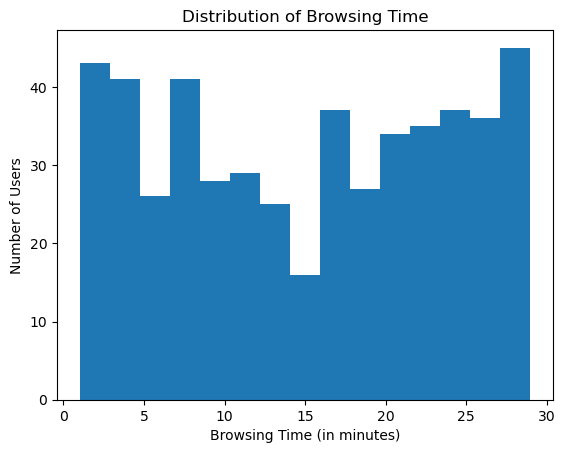

In [11]:
plt.figure()
plt.hist(df["Browsing_Time"], bins=15)
plt.xlabel("Browsing Time (in minutes)")   
plt.ylabel("Number of Users")              
plt.title("Distribution of Browsing Time")
plt.show()

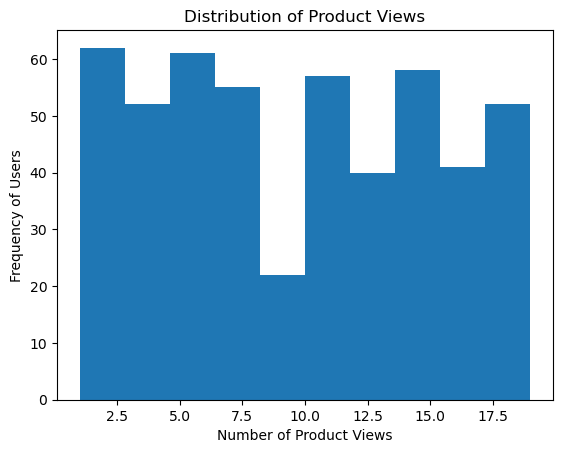

In [12]:
plt.figure()
plt.hist(df["Product_Views"], bins=10)
plt.xlabel("Number of Product Views")
plt.ylabel("Frequency of Users")
plt.title("Distribution of Product Views")
plt.show()

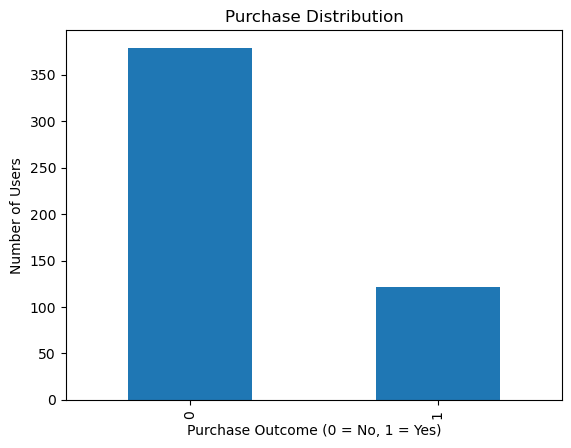

In [13]:
plt.figure()
df["Purchase"].value_counts().plot(kind="bar")
plt.xlabel("Purchase Outcome (0 = No, 1 = Yes)")
plt.ylabel("Number of Users")
plt.title("Purchase Distribution")
plt.show()

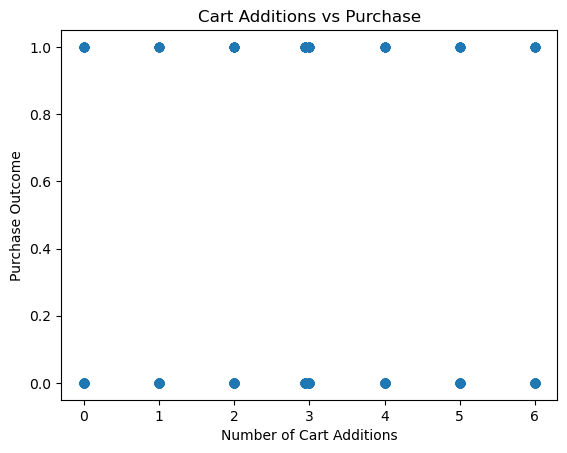

In [14]:
plt.figure()
plt.scatter(df["Cart_Additions"], df["Purchase"])
plt.xlabel("Number of Cart Additions")
plt.ylabel("Purchase Outcome")
plt.title("Cart Additions vs Purchase")
plt.show()

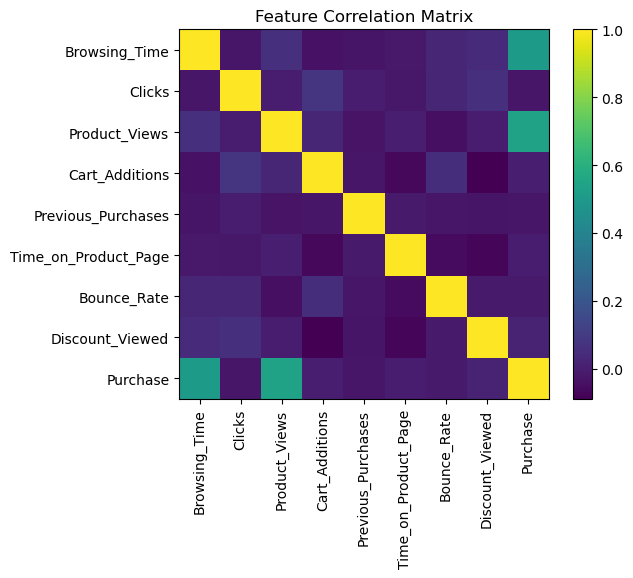

In [15]:
plt.figure()
corr = df.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.show()

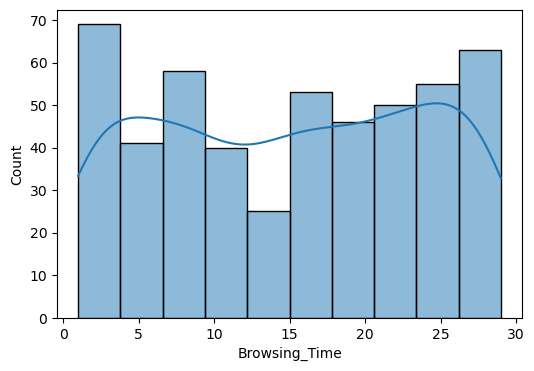

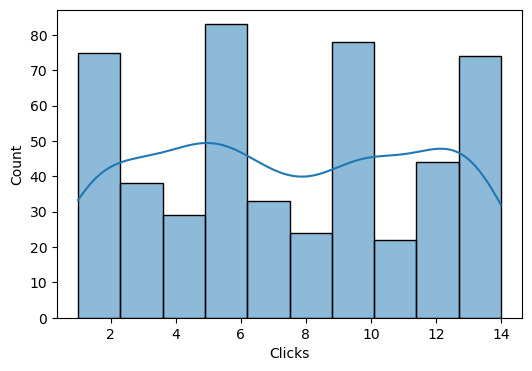

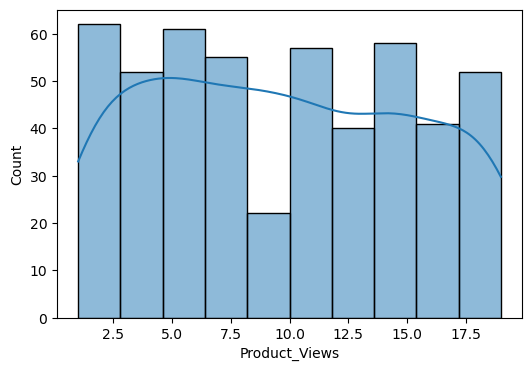

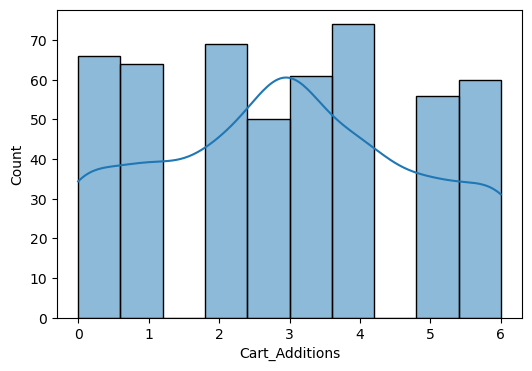

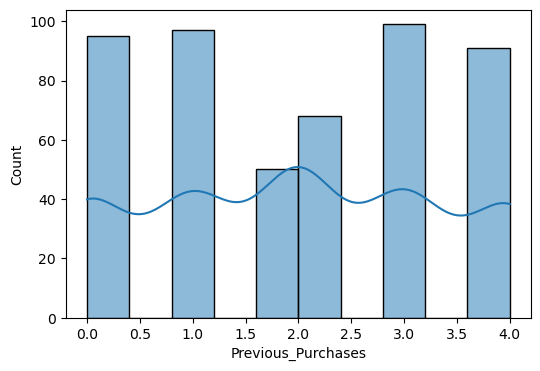

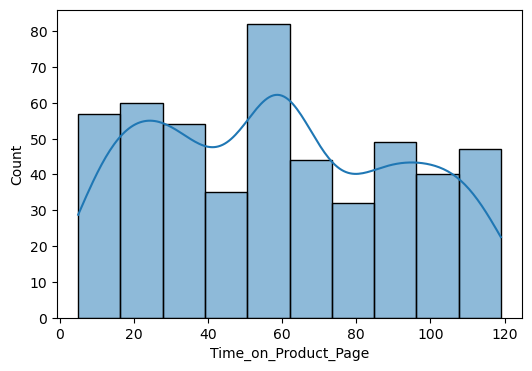

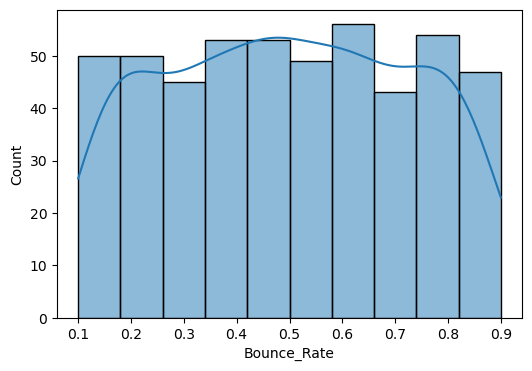

In [16]:
numeric_columns=['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

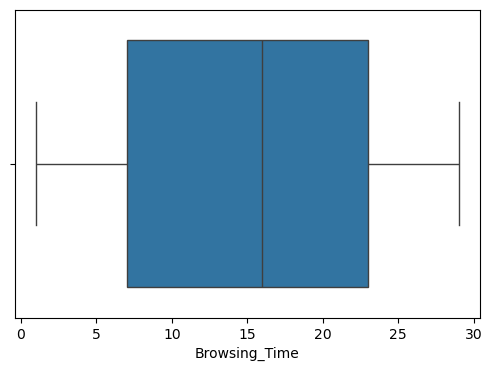

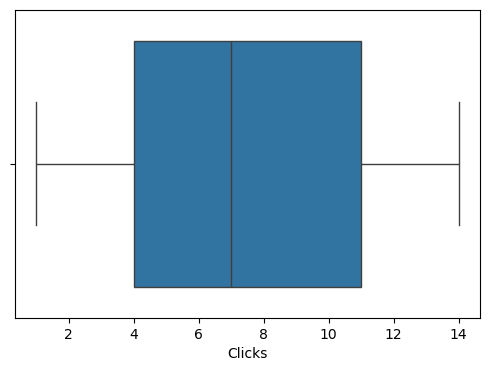

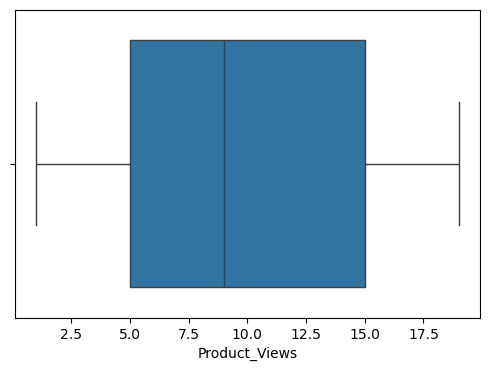

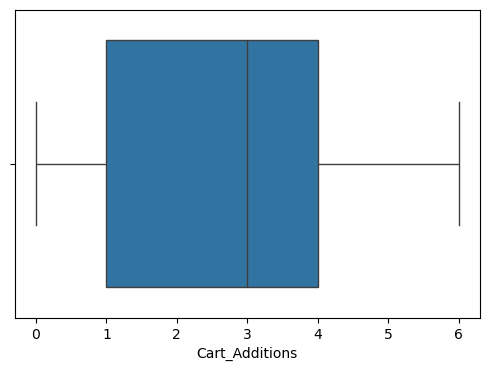

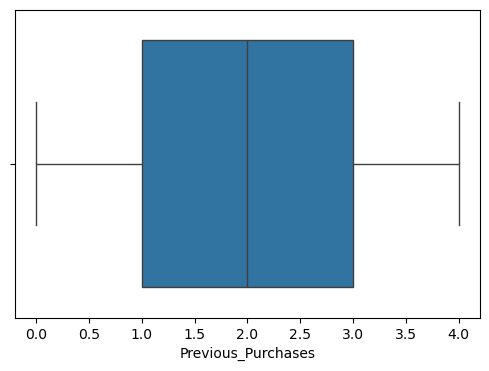

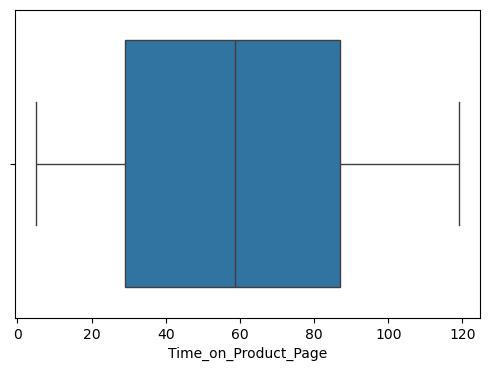

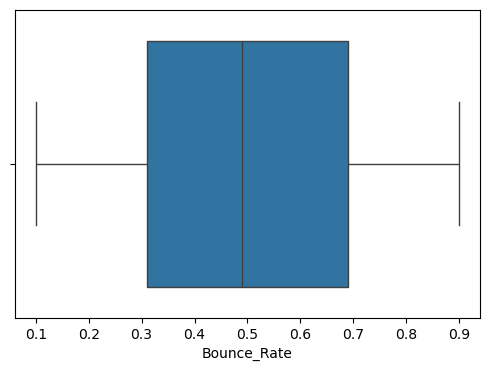

In [17]:
numeric_columns=['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

In [18]:
# Loop through all columns except target
for col in df.columns[:-1]:   # excluding 'Purchase'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 0
Clicks -> Number of Outliers: 0
Product_Views -> Number of Outliers: 0
Cart_Additions -> Number of Outliers: 0
Previous_Purchases -> Number of Outliers: 0
Time_on_Product_Page -> Number of Outliers: 0
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


In [19]:
cols_to_scale = ["Browsing_Time","Clicks","Product_Views","Cart_Additions","Previous_Purchases","Time_on_Product_Page","Bounce_Rate"]
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,-0.917495,-1.321947,-1.377872,-0.499344,0.000000,-1.301014,0.063818,1,0
1,0.552850,-1.321947,-0.659856,-1.033085,-1.448987,1.715388,-0.198448,1,0
2,1.570781,-0.106922,-1.557376,0.568137,0.739081,-0.173672,-1.203802,1,0
3,-0.012668,-0.349927,0.955679,0.034397,-1.448987,-0.386953,-0.591848,0,0
4,-0.465081,-1.078942,0.058159,0.034397,0.000000,0.000000,-0.198448,0,0
...,...,...,...,...,...,...,...,...,...
495,-0.351978,-1.321947,0.237663,1.101878,0.009725,-0.752577,0.194951,0,0
496,0.439746,-1.321947,-0.300849,-1.566825,0.739081,0.100547,0.151240,0,0
497,0.892160,1.594112,0.058159,-0.499344,1.468437,1.441170,0.938039,0,0
498,-0.012668,0.865098,-0.480353,1.101878,0.000000,-0.722108,1.200306,1,0


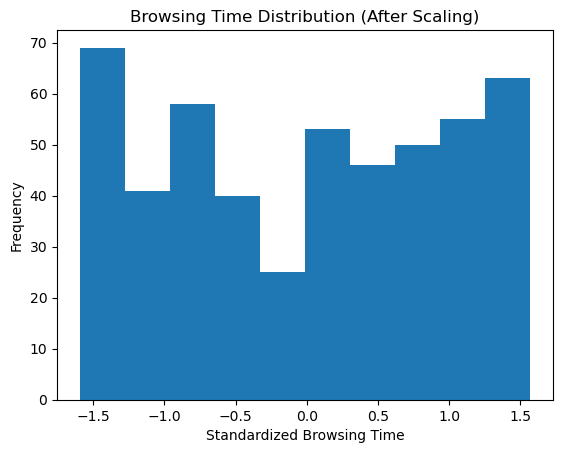

In [20]:
plt.hist(df["Browsing_Time"], bins=10)
plt.xlabel("Standardized Browsing Time")
plt.ylabel("Frequency")
plt.title("Browsing Time Distribution (After Scaling)")
plt.show()

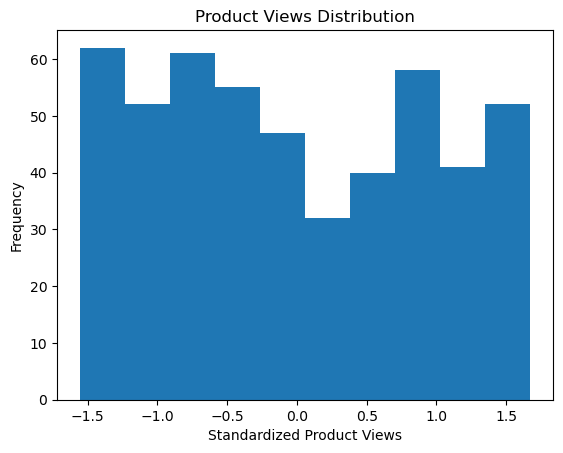

In [21]:
plt.hist(df["Product_Views"], bins=10)
plt.xlabel("Standardized Product Views")
plt.ylabel("Frequency")
plt.title("Product Views Distribution")
plt.show()

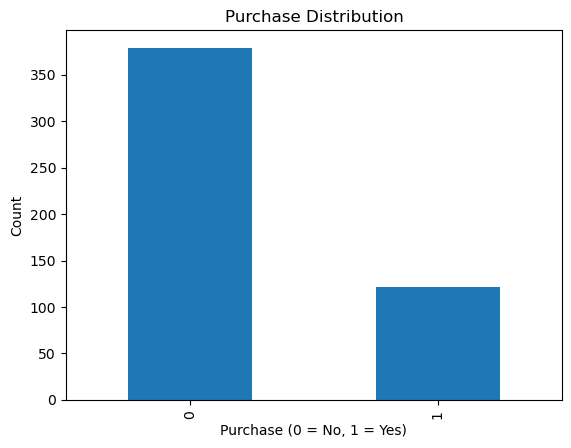

In [22]:
df["Purchase"].value_counts().plot(kind="bar")
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Purchase Distribution")
plt.show()

In [23]:
for col in df.columns[:-1]:   # excluding 'Purchase'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 0
Clicks -> Number of Outliers: 0
Product_Views -> Number of Outliers: 0
Cart_Additions -> Number of Outliers: 0
Previous_Purchases -> Number of Outliers: 0
Time_on_Product_Page -> Number of Outliers: 0
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


In [24]:
corr = df.corr()
print(corr)

                      Browsing_Time    Clicks  Product_Views  Cart_Additions  \
Browsing_Time              1.000000 -0.025266       0.057990       -0.036333   
Clicks                    -0.025266  1.000000      -0.006431        0.076587   
Product_Views              0.057990 -0.006431       1.000000        0.028473   
Cart_Additions            -0.036333  0.076587       0.028473        1.000000   
Previous_Purchases        -0.028017 -0.004528      -0.032839       -0.024718   
Time_on_Product_Page      -0.016677 -0.020160       0.000145       -0.064531   
Bounce_Rate                0.027792  0.026559      -0.045501        0.054446   
Discount_Viewed            0.043407  0.062747      -0.003299       -0.089610   
Purchase                   0.504099 -0.021833       0.537475        0.001429   

                      Previous_Purchases  Time_on_Product_Page  Bounce_Rate  \
Browsing_Time                  -0.028017             -0.016677     0.027792   
Clicks                         -0.004528 

In [25]:
print(corr["Purchase"])

Browsing_Time           0.504099
Clicks                 -0.021833
Product_Views           0.537475
Cart_Additions          0.001429
Previous_Purchases     -0.022388
Time_on_Product_Page   -0.005378
Bounce_Rate            -0.011908
Discount_Viewed         0.013418
Purchase                1.000000
Name: Purchase, dtype: float64


In [26]:
selected_features = []

for col in corr.columns:
    if col != "Purchase":
        if abs(corr[col]["Purchase"]) > 0.1:
            selected_features.append(col)

print("Selected Features:", selected_features)

Selected Features: ['Browsing_Time', 'Product_Views']


In [86]:
X=df[selected_features]
y=df["Purchase"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [109]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=2),
    "SVM": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy')
}
results = {}
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.9200
Precision: 0.7692
Recall: 0.9091
F1 Score: 0.8333

KNN
Accuracy: 0.9900
Precision: 0.9565
Recall: 1.0000
F1 Score: 0.9778

SVM
Accuracy: 0.9700
Precision: 0.8800
Recall: 1.0000
F1 Score: 0.9362

Decision Tree
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [108]:
results_df = pd.DataFrame(results).T
print("\nFinal Comparison Table:\n")
print(results_df)


Final Comparison Table:

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression      0.92   0.769231  0.909091  0.833333
KNN                      0.99   0.956522  1.000000  0.977778
SVM                      0.97   0.880000  1.000000  0.936170
Decision Tree            1.00   1.000000  1.000000  1.000000


In [ ]:
#Decision tree is overfitting so we will be choosing KNN